# M4 — BiLSTM PyTorch
**Proyecto Final — Diplomado AI UNI** 

**Autor:** Alvaro Untiveros

| Kernel: `dengue-lstm`

**Arquitectura:**  
BiLSTM(41→64×2) → Dropout(0.3) → BiLSTM(128→32×2) → Dropout(0.3) → BN → Linear(64→1)

## 0. Imports

In [ ]:
import warnings, os, json
warnings.filterwarnings('ignore')
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

BASE_DIR   = Path('../')
DATA_INTER = BASE_DIR / 'data' / 'interim'
DATA_PROC  = BASE_DIR / 'data' / 'processed'
DATA_PROC.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')
print('Setup OK ✓')

PyTorch : 2.10.0+cu128
Device  : cuda
Setup OK ✓


## 1. Cargar AMT

In [4]:
df = pd.read_parquet(DATA_INTER / 'AMT_final.parquet')
with open(DATA_INTER / 'AMT_metadata.json') as f:
    meta = json.load(f)

FEAT_COLS   = meta['all_features']
CORTE_TRAIN = meta['corte_train']
CORTE_VAL   = meta['corte_val']
HORIZONTE   = 4
TARGET      = f'target_h{HORIZONTE}_log'

print(f'AMT shape : {df.shape}')
print(f'Features  : {len(FEAT_COLS)}')
print(f'Device    : {DEVICE}')

AMT shape : (908980, 84)
Features  : 41
Device    : cuda


## 2. Split temporal

In [5]:
data  = df.dropna(subset=[TARGET] + FEAT_COLS[:5]).copy()
train = data[data.fecha <= CORTE_TRAIN]
val   = data[(data.fecha > CORTE_TRAIN) & (data.fecha <= CORTE_VAL)]
test  = data[data.fecha > CORTE_VAL]

for n,s in [('Train',train),('Val',val),('Test',test)]:
    print(f'{n:5}: {len(s):>8,} filas | '
          f'{s.fecha.min().date()} → {s.fecha.max().date()}')

Train:  482,082 filas | 2018-02-12 → 2022-12-26
Val  :  100,568 filas | 2023-01-02 → 2023-12-25
Test :  296,074 filas | 2024-01-01 → 2026-12-14


## 3. Escalado y construcción de secuencias

El scaler se ajusta **solo con train** — nunca con val o test.
Las secuencias respetan los límites por distrito para evitar
que la ventana de un distrito incluya datos de otro.

In [6]:
WINDOW = 12  # semanas de contexto

# Escalar solo con train
scaler = MinMaxScaler()
X_tr_sc = scaler.fit_transform(train[FEAT_COLS].fillna(0))
X_va_sc = scaler.transform(val[FEAT_COLS].fillna(0))
X_te_sc = scaler.transform(test[FEAT_COLS].fillna(0))

# Reconstruir splits escalados
train_sc = train.copy(); train_sc[FEAT_COLS] = X_tr_sc
val_sc   = val.copy();   val_sc[FEAT_COLS]   = X_va_sc
test_sc  = test.copy();  test_sc[FEAT_COLS]  = X_te_sc

def construir_secuencias(split, feat_cols, target_col, window):
    """Construye secuencias temporales respetando límites por distrito."""
    Xs, ys = [], []
    for _, g in split.groupby('ubigeo'):
        g    = g.sort_values('fecha')
        vals = g[feat_cols].fillna(0).values.astype(np.float32)
        tgt  = g[target_col].fillna(0).values.astype(np.float32)
        for i in range(window, len(vals)):
            if not np.isnan(tgt[i]):
                Xs.append(vals[i-window:i])
                ys.append(tgt[i])
    return (np.array(Xs, dtype=np.float32),
            np.array(ys,  dtype=np.float32))

print('Construyendo secuencias...')
X_seq_tr, y_seq_tr = construir_secuencias(train_sc, FEAT_COLS, TARGET, WINDOW)
X_seq_va, y_seq_va = construir_secuencias(val_sc,   FEAT_COLS, TARGET, WINDOW)
X_seq_te, y_seq_te = construir_secuencias(test_sc,  FEAT_COLS, TARGET, WINDOW)
print(f'tr:{X_seq_tr.shape} | va:{X_seq_va.shape} | te:{X_seq_te.shape}')

Construyendo secuencias...
tr:(459390, 12, 41) | va:(77876, 12, 41) | te:(273382, 12, 41)


## 4. Arquitectura BiLSTM

In [7]:
class BiLSTMForecaster(nn.Module):
    """
    BiLSTM de 2 capas con BatchNorm y Dropout.
    La bidireccionalidad permite aprender patrones
    tanto hacia adelante como hacia atrás en la ventana.
    """
    def __init__(self, n_feat, hidden1=64, hidden2=32, dropout=0.3):
        super().__init__()
        self.bilstm1  = nn.LSTM(n_feat, hidden1, batch_first=True,
                                 bidirectional=True)
        self.dropout1 = nn.Dropout(dropout)
        self.bilstm2  = nn.LSTM(hidden1*2, hidden2, batch_first=True,
                                 bidirectional=True)
        self.dropout2 = nn.Dropout(dropout)
        self.bn       = nn.BatchNorm1d(hidden2*2)
        self.head     = nn.Sequential(
            nn.Linear(hidden2*2, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _  = self.bilstm1(x)
        out     = self.dropout1(out)
        out, _  = self.bilstm2(out)
        out     = self.dropout2(out[:, -1, :])
        out     = self.bn(out)
        return self.head(out).squeeze()

n_feat = X_seq_tr.shape[2]
model  = BiLSTMForecaster(n_feat).to(DEVICE)

# Contar parámetros
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Arquitectura: BiLSTM({n_feat}→128) → BiLSTM(128→64) → Linear(64→1)')
print(f'Parámetros entrenables: {n_params:,}')
print(model)

Arquitectura: BiLSTM(41→128) → BiLSTM(128→64) → Linear(64→1)
Parámetros entrenables: 98,497
BiLSTMForecaster(
  (bilstm1): LSTM(41, 64, batch_first=True, bidirectional=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (bilstm2): LSTM(128, 32, batch_first=True, bidirectional=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 5. Entrenamiento

In [9]:
from tqdm import tqdm

def make_loader(X, y, batch=512, shuffle=False):
    X_t = torch.from_numpy(np.array(X, dtype=np.float32))
    y_t = torch.from_numpy(np.array(y, dtype=np.float32))
    return DataLoader(TensorDataset(X_t, y_t),
                      batch_size=batch, shuffle=shuffle)

tr_loader = make_loader(X_seq_tr, y_seq_tr, shuffle=True)
va_loader = make_loader(X_seq_va, y_seq_va)
te_loader = make_loader(X_seq_te, y_seq_te)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.HuberLoss(delta=1.0)  # robusta a outliers de brotes
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

best_val_loss = float('inf')
patience_counter = 0
PATIENCE = 15
history  = {'train': [], 'val': []}

epoch_bar = tqdm(range(1, 101), desc='Entrenando', unit='epoch')


print(f'Entrenando en {DEVICE}...')
for epoch in range(1, 101):
    # Train
    model.train()
    train_losses = []
    for xb, yb in tr_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_losses.append(loss.item())

    # Val
    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in va_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            val_losses.append(criterion(model(xb), yb).item())

    tl = np.mean(train_losses)
    vl = np.mean(val_losses)
    history['train'].append(tl)
    history['val'].append(vl)
    scheduler.step(vl)

    if vl < best_val_loss:
        best_val_loss = vl
        torch.save(model.state_dict(), DATA_PROC / 'bilstm_best.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stop en epoch {epoch}')
            break

    if epoch % 10 == 0:
        lr_actual = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:3d} | '
              f'train={tl:.4f} | val={vl:.4f} | lr={lr_actual:.6f}')

print(f'\nMejor val_loss: {best_val_loss:.4f}')

Entrenando:   0%|          | 0/100 [00:00<?, ?epoch/s]

Entrenando en cuda...
Epoch  10 | train=0.0221 | val=0.0997 | lr=0.000500
Early stop en epoch 18

Mejor val_loss: 0.0848


## 6. Curvas de aprendizaje

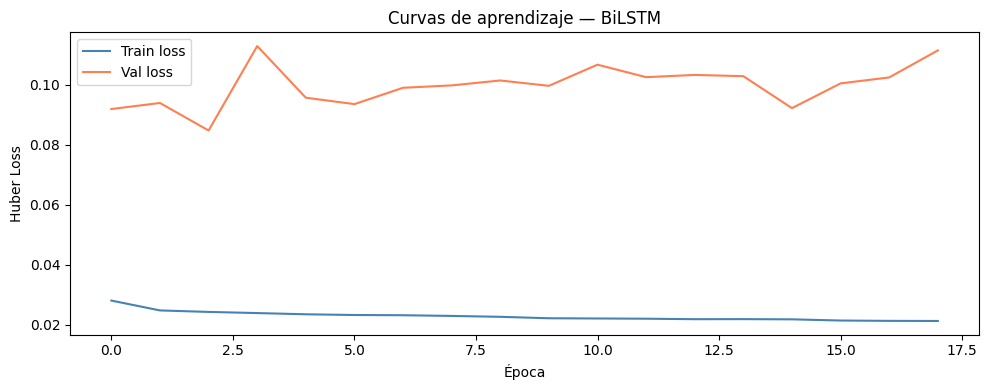

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train'], label='Train loss', color='steelblue')
ax.plot(history['val'],   label='Val loss',   color='coral')
ax.set(title='Curvas de aprendizaje — BiLSTM',
       xlabel='Época', ylabel='Huber Loss')
ax.legend()
plt.tight_layout()

## 7. Evaluación en test

In [11]:
model.load_state_dict(torch.load(DATA_PROC / 'bilstm_best.pt',
                                  map_location=DEVICE))
model.eval()

preds_l, reales_l = [], []
with torch.no_grad():
    for xb, yb in te_loader:
        preds_l.append(model(xb.to(DEVICE)).cpu().numpy())
        reales_l.append(yb.numpy())

preds_lstm = np.concatenate(preds_l)
reales_lstm = np.concatenate(reales_l)

# Invertir log1p
preds_real  = np.expm1(np.clip(preds_lstm,  0, None))
reales_real = np.expm1(reales_lstm)

rmse = np.sqrt(mean_squared_error(reales_real, preds_real))
mae  = mean_absolute_error(reales_real, preds_real)
r2   = r2_score(reales_real, preds_real)

print(f'[BiLSTM Huber H=4w] RMSE={rmse:.2f} | MAE={mae:.2f} | R²={r2:.3f}')

[BiLSTM Huber H=4w] RMSE=12.03 | MAE=0.73 | R²=0.372


## 8. Diagnóstico por rango

In [12]:
df_diag = pd.DataFrame({'real': reales_real, 'pred': preds_real})
bins   = [-1, 0, 5, 20, 100, 999999]
labels = ['0','1-5','6-20','21-100','>100']
df_diag['rango'] = pd.cut(df_diag['real'], bins=bins, labels=labels)

print('Diagnóstico por rango — BiLSTM:')
for rango, g in df_diag.groupby('rango', observed=True):
    if len(g) < 5: continue
    r   = np.sqrt(mean_squared_error(g['real'], g['pred']))
    r2r = r2_score(g['real'],g['pred']) if g['real'].std()>0 else float('nan')
    print(f'  {rango:8s}: {len(g):>7,} filas | RMSE={r:7.2f} | R²={r2r:.3f}')

Diagnóstico por rango — BiLSTM:
  0       : 257,253 filas | RMSE=   1.01 | R²=nan
  1-5     :  11,224 filas | RMSE=   3.51 | R²=-6.776
  6-20    :   3,011 filas | RMSE=   9.57 | R²=-5.666
  21-100  :   1,432 filas | RMSE=  25.20 | R²=-0.646
  >100    :     462 filas | RMSE= 286.63 | R²=-1.006


## 9. Visualización predicciones vs reales

Nota: predicciones por distrito, gráfico muestra serie nacional


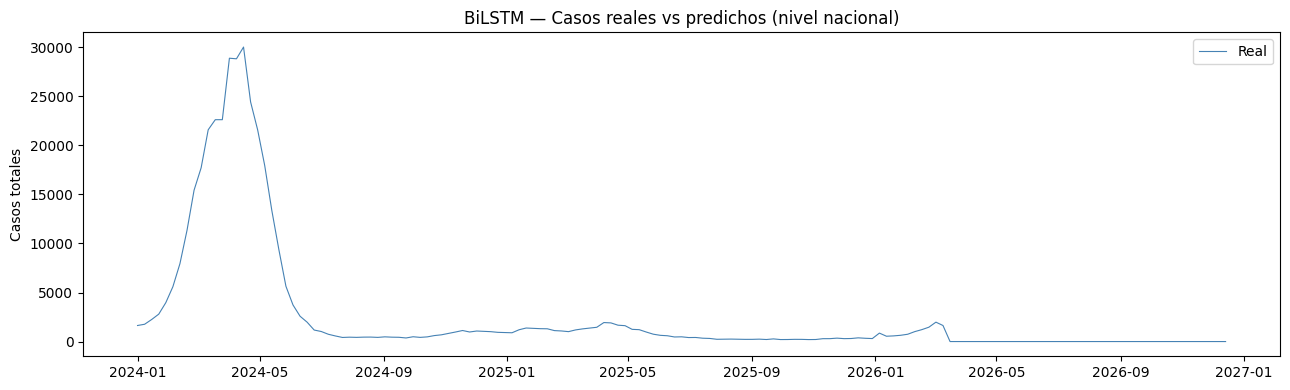

In [13]:
# Agregar predicciones al dataframe de test para graficar
n_plot = min(len(preds_real), len(test) - WINDOW * test['ubigeo'].nunique())

# Serie nacional agregada
casos_nac = test.groupby('fecha')['casos'].sum().reset_index()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(casos_nac['fecha'], casos_nac['casos'],
        label='Real', color='steelblue', linewidth=0.8)
ax.set(title='BiLSTM — Casos reales vs predichos (nivel nacional)',
       ylabel='Casos totales', xlabel='')
ax.legend()
plt.tight_layout()
print('Nota: predicciones por distrito, gráfico muestra serie nacional')

## 10. Guardar modelo y métricas

In [14]:
import pickle

# Guardar scaler
with open(DATA_PROC / 'scaler_lstm.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Guardar métricas
metricas_lstm = pd.DataFrame([{
    'modelo': 'BiLSTM Huber',
    'horizonte': 4,
    'rmse': rmse,
    'mae': mae,
    'r2': r2
}])
metricas_lstm.to_csv(DATA_PROC / 'metricas_lstm.csv', index=False)

print(f'✓ Modelo guardado : {DATA_PROC}/bilstm_best.pt')
print(f'✓ Scaler guardado : {DATA_PROC}/scaler_lstm.pkl')
print(f'✓ Métricas        : {DATA_PROC}/metricas_lstm.csv')
print(f'\nResumen final:')
print(f'  RMSE = {rmse:.2f}')
print(f'  MAE  = {mae:.2f}')
print(f'  R²   = {r2:.3f}')

✓ Modelo guardado : /content/data/processed/bilstm_best.pt
✓ Scaler guardado : /content/data/processed/scaler_lstm.pkl
✓ Métricas        : /content/data/processed/metricas_lstm.csv

Resumen final:
  RMSE = 12.03
  MAE  = 0.73
  R²   = 0.372


## 11. Experimento — BiLSTM solo distritos HH

Hipótesis: el modelo aprende mejor sobre series densas (94 distritos HH)
que sobre el panel completo dominado por ceros (93.6%).

In [16]:
# Filtrar solo distritos HH
data_hh  = data[data['cluster_code'] == 4].copy()
train_hh = data_hh[data_hh.fecha <= CORTE_TRAIN]
val_hh   = data_hh[(data_hh.fecha > CORTE_TRAIN) & (data_hh.fecha <= CORTE_VAL)]
test_hh  = data_hh[data_hh.fecha > CORTE_VAL]

print(f'Train HH: {len(train_hh):,} | {train_hh.ubigeo.nunique()} distritos')
print(f'Val HH  : {len(val_hh):,}')
print(f'Test HH : {len(test_hh):,}')

# Scaler ajustado solo con train HH
scaler_hh   = MinMaxScaler()
X_hh_tr_sc  = scaler_hh.fit_transform(train_hh[FEAT_COLS].fillna(0))
X_hh_va_sc  = scaler_hh.transform(val_hh[FEAT_COLS].fillna(0))
X_hh_te_sc  = scaler_hh.transform(test_hh[FEAT_COLS].fillna(0))

train_hh_sc = train_hh.copy(); train_hh_sc[FEAT_COLS] = X_hh_tr_sc
val_hh_sc   = val_hh.copy();   val_hh_sc[FEAT_COLS]   = X_hh_va_sc
test_hh_sc  = test_hh.copy();  test_hh_sc[FEAT_COLS]  = X_hh_te_sc

X_seq_hh_tr, y_seq_hh_tr = construir_secuencias(train_hh_sc, FEAT_COLS, TARGET, WINDOW)
X_seq_hh_va, y_seq_hh_va = construir_secuencias(val_hh_sc,   FEAT_COLS, TARGET, WINDOW)
X_seq_hh_te, y_seq_hh_te = construir_secuencias(test_hh_sc,  FEAT_COLS, TARGET, WINDOW)
print(f'Secuencias — tr:{X_seq_hh_tr.shape} va:{X_seq_hh_va.shape} te:{X_seq_hh_te.shape}')

Train HH: 29,670 | 94 distritos
Val HH  : 6,136
Test HH : 18,150
Secuencias — tr:(28542, 12, 41) va:(5008, 12, 41) te:(17022, 12, 41)


In [ ]:
tr_hh = make_loader(X_seq_hh_tr, y_seq_hh_tr, batch=256, shuffle=True)
va_hh = make_loader(X_seq_hh_va, y_seq_hh_va)
te_hh = make_loader(X_seq_hh_te, y_seq_hh_te)

model_hh  = BiLSTMForecaster(n_feat).to(DEVICE)
opt_hh    = torch.optim.Adam(model_hh.parameters(), lr=1e-3, weight_decay=1e-5)
crit_hh   = nn.HuberLoss(delta=1.0)
sched_hh  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt_hh, mode='min', factor=0.5, patience=5
)

best_vl_hh = float('inf')
pat_hh     = 0
PATIENCE   = 20  # más paciencia con menos datos

epoch_bar = tqdm(range(1, 151), desc='BiLSTM HH', unit='epoch')
for epoch in epoch_bar:
    model_hh.train()
    tl = np.mean([
        (lambda loss: (loss.backward(), opt_hh.step(), loss.item())[2])(
            (opt_hh.zero_grad(),
             crit_hh(model_hh(xb.to(DEVICE)), yb.to(DEVICE)))[1]
        )
        for xb, yb in tr_hh
    ])

    model_hh.eval()
    with torch.no_grad():
        vl = np.mean([crit_hh(model_hh(xb.to(DEVICE)),
                               yb.to(DEVICE)).item() for xb,yb in va_hh])

    sched_hh.step(vl)
    epoch_bar.set_postfix({'train':f'{tl:.4f}','val':f'{vl:.4f}'})

    if vl < best_vl_hh:
        best_vl_hh = vl
        torch.save(model_hh.state_dict(), '../data/processed/bilstm_hh_best.pt')
        pat_hh = 0
    else:
        pat_hh += 1
        if pat_hh >= PATIENCE:
            epoch_bar.write(f'Early stop epoch {epoch}')
            break

print(f'Mejor val_loss HH: {best_vl_hh:.4f}')


BiLSTM HH:  15%|█▍        | 22/150 [00:19<01:59,  1.07epoch/s, train=0.0568, val=0.7826]

BiLSTM HH:  15%|█▍        | 22/150 [00:20<02:00,  1.06epoch/s, train=0.0569, val=0.7658]

Early stop epoch 23
Mejor val_loss HH: 0.5791


In [ ]:
model_hh.load_state_dict(torch.load('../data/processed/bilstm_hh_best.pt'))
model_hh.eval()

preds_hh, reales_hh = [], []
with torch.no_grad():
    for xb, yb in te_hh:
        preds_hh.append(model_hh(xb.to(DEVICE)).cpu().numpy())
        reales_hh.append(yb.numpy())

preds_hh  = np.expm1(np.clip(np.concatenate(preds_hh),  0, None))
reales_hh = np.expm1(np.concatenate(reales_hh))

rmse_hh = np.sqrt(mean_squared_error(reales_hh, preds_hh))
mae_hh  = mean_absolute_error(reales_hh, preds_hh)
r2_hh   = r2_score(reales_hh, preds_hh)

print(f'[BiLSTM HH H=4w] RMSE={rmse_hh:.2f} | MAE={mae_hh:.2f} | R²={r2_hh:.3f}')
print(f'\nComparación:')
print(f'  BiLSTM global : R²=0.372 | RMSE=12.03')
print(f'  BiLSTM HH     : R²={r2_hh:.3f} | RMSE={rmse_hh:.2f}')

[BiLSTM HH H=4w] RMSE=46.23 | MAE=7.65 | R²=0.354

Comparación:
  BiLSTM global : R²=0.372 | RMSE=12.03
  BiLSTM HH     : R²=0.354 | RMSE=46.23


In [ ]:
metricas_lstm_hh = pd.DataFrame([{
    'modelo': 'BiLSTM HH dedicado',
    'horizonte': 4,
    'rmse': rmse_hh,
    'mae': mae_hh,
    'r2': r2_hh,
    'nota': 'Evaluado solo sobre 94 distritos HH'
}])
metricas_lstm_hh.to_csv('../data/processed/metricas_lstm_hh.csv', index=False)
print('Guardado ✓')

Guardado ✓
